In [16]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [17]:
df = pd.read_csv("Social_Network_Ads.csv")

print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0


In [18]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


In [19]:
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [20]:
X = df[
    [
        "Age",
        "EstimatedSalary"
    ]
]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [21]:
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(
    eps=0.3,
    min_samples=4
)

In [22]:
clusters = dbscan.fit_predict(X_scaled)

In [23]:
df["Cluster"] = clusters

print("\nCluster Summary")
print(df["Cluster"].value_counts())

for i in sorted(df["Cluster"].unique()):

    print("\n" + "="*50)

    if i == -1:
        print("NOISE POINTS")
    else:
        print("CLUSTER", i + 1)

    print("="*50)

    cluster_data = df[
        df["Cluster"] == i
    ]

    print(
        cluster_data[
            [
                "Age",
                "EstimatedSalary"
            ]
        ]
    )

    print(
        "\nTotal Records :",
        len(cluster_data)
    )


Cluster Summary
Cluster
 0    290
 2     52
 5     15
 3     14
 1     12
-1     12
 4      5
Name: count, dtype: int64

NOISE POINTS
     Age  EstimatedSalary
31    27           137000
48    30           135000
147   41            30000
159   32           135000
172   26           118000
197   20            36000
219   59           143000
334   57            60000
336   58           144000
346   53            72000
356   54            70000
385   56            60000

Total Records : 12

CLUSTER 1
     Age  EstimatedSalary
0     19            19000
1     35            20000
2     26            43000
3     27            57000
4     19            76000
..   ...              ...
378   41            87000
380   42            64000
387   39            71000
394   39            59000
398   36            33000

[290 rows x 2 columns]

Total Records : 290

CLUSTER 2
     Age  EstimatedSalary
7     32           150000
103   33           149000
168   29           148000
202   39           13400

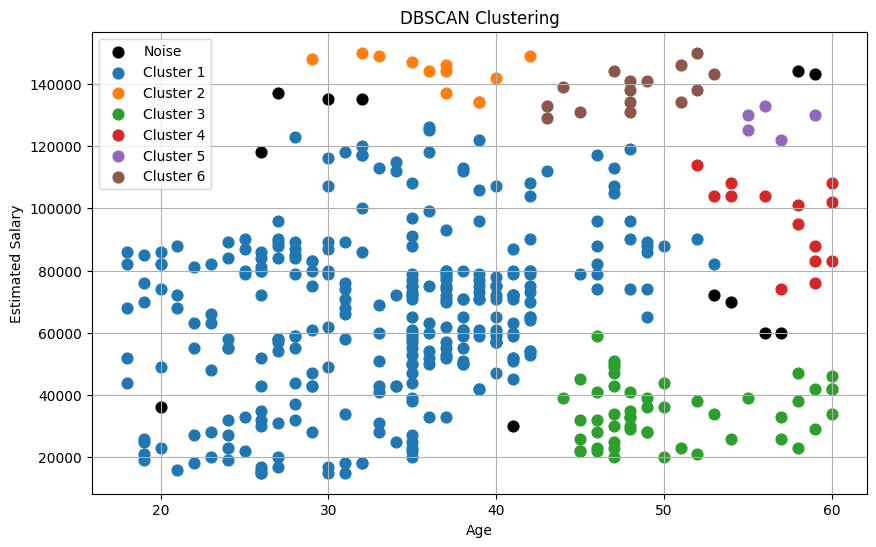

In [26]:
plt.figure(figsize=(10,6))

for cluster in sorted(df["Cluster"].unique()):

    cluster_data = df[
        df["Cluster"] == cluster
    ]

    if cluster == -1:

        plt.scatter(
            cluster_data["Age"],
            cluster_data["EstimatedSalary"],
            color="black",
            label="Noise",
            s=60
        )

    else:

        plt.scatter(
            cluster_data["Age"],
            cluster_data["EstimatedSalary"],
            label=f"Cluster {cluster+1}",
            s=60
        )

plt.xlabel("Age")
plt.ylabel("Estimated Salary")

plt.title("DBSCAN Clustering")

plt.legend()
plt.grid(True)

plt.show()